## 🔍 Exploratory Data Analysis (EDA) — Wildfire Patterns in California

In this notebook, we begin the second step of the Data Science Methodology (DSM): **Data Understanding**. The primary goal here is to analyze both real and simulated wildfire data to uncover patterns and trends across California from 2013–2019.

We'll be focusing on:
- Temporal and seasonal trends in wildfire occurrences
- Geographic distribution of fire events across counties and regions
- Comparison between wildfire and non-wildfire events (simulated data)
- What weather pattern trends correlates to wildfire occurences

This stage is crucial for building intuition around the dataset and identifying key features for later modeling.

In [1]:
#Import pandas, matplotlib.pyplot, and seaborn in the correct lines below
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os
import requests
import pandas as pd
import time

In [2]:
file_path = "..\\data\\cleaned_wildfire_data.csv" 
wildfire = pd.read_csv(file_path)

In [3]:
wildfire.sample(8)

,Latitude,Longitude,ArchiveYear,Started,AcresBurned,Counties,WildfireOccurred,Region,Date
450,34.609000,-120.454000,2014,2014-05-13 14:00:00+00:00,632,Santa Barbara,1,Southern California,5/13/2014
1742,36.153560,-118.741030,2017,2017-08-29 08:29:00+00:00,36556,Tulare,1,Central California,8/29/2017
1962,34.698629,-119.473823,2018,2018-02-09 00:57:00+00:00,0,Santa Barbara,0,Southern California,2/9/2018
2811,34.183000,-117.285000,2019,2019-10-31 06:53:47+00:00,200,San Bernardino,1,Southern California,10/31/2019
2616,37.962557,-121.468074,2019,2019-07-16 18:44:15+00:00,90,San Joaquin,1,Central California,7/16/2019
2625,38.481258,-122.143942,2019,2019-07-22 15:05:34+00:00,64,Napa,1,Western California,7/22/2019
2413,39.032362,-121.109133,2019,2019-01-07 02:57:00+00:00,0,Nevada,0,Northern California,1/7/2019
1151,38.699710,-122.154570,2016,2016-06-26 15:45:00+00:00,277,Yolo,1,Central California,6/26/2016


In [4]:
wildfire['Started'].dtype

dtype('O')

In [129]:
def get_season(dt):
    month = dt.month
    day = dt.day

    if (month == 12 and day >= 21) or (1 <= month <= 3 and (month != 3 or day < 20)):
        return 'Winter'
    elif (month == 3 and day >= 20) or (4 <= month <= 6 and (month != 6 or day < 21)):
        return 'Spring'
    elif (month == 6 and day >= 21) or (7 <= month <= 9 and (month != 9 or day < 22)):
        return 'Summer'
    else:
        return 'Fall'
    
wildfire['Started'] = pd.to_datetime(wildfire['Started'])
wildfire['Season'] = wildfire['Started'].apply(get_season)

In [130]:
wildfire.sample(5)

,Latitude,Longitude,ArchiveYear,Started,AcresBurned,Counties,WildfireOccurred,Region,Date,Temperature,Humidity,WindSpeed,Precipitation,Season
1428,38.170442,-120.641159,2017,2017-04-01 19:44:00+00:00,0,Calaveras,0,Central California,4/1/2017,13.1,58.0,9.5,0.0,Spring
26,40.151660,-121.327220,2013,2013-02-19 22:39:00+00:00,0,Plumas,0,Northern California,2/19/2013,-2.9,91.0,13.2,11.5,Winter
2448,34.177705,-118.062588,2019,2019-02-24 08:16:00+00:00,0,Los Angeles,0,Southern California,2/24/2019,9.3,59.0,4.8,0.0,Winter
1045,33.708817,-117.234151,2016,2016-03-12 16:37:00+00:00,0,Riverside,0,Southern California,3/12/2016,9.5,81.0,8.2,6.9,Winter
2542,34.037024,-114.897912,2019,2019-05-27 06:33:00+00:00,0,Riverside,0,Southern California,5/27/2019,18.4,34.0,15.8,0.3,Spring


In [131]:
cols = list(wildfire.columns)
cols.insert(8, cols.pop(cols.index('Season')))
wildfire = wildfire[cols]

In [133]:
wildfire.sample(5)

,Latitude,Longitude,ArchiveYear,Started,AcresBurned,Counties,WildfireOccurred,Region,Season,Date,Temperature,Humidity,WindSpeed,Precipitation
1044,39.334534,-120.566199,2016,2016-03-12 09:47:00+00:00,0,Nevada,0,Northern California,Winter,3/12/2016,-1.6,92.0,17.0,10.6
2010,37.072985,-121.658144,2018,2018-04-04 11:40:00+00:00,0,Santa Clara,0,Western California,Spring,4/4/2018,14.8,73.0,4.3,0.0
506,41.489000,-120.904000,2014,2014-07-03 15:46:00+00:00,1469,Modoc,1,Northern California,Summer,7/3/2014,24.6,34.0,7.5,0.0
367,37.081964,-121.987299,2014,2014-02-05 08:04:00+00:00,0,Santa Cruz,0,Western California,Winter,2/5/2014,6.6,74.0,5.4,0.0
1725,39.986400,-120.897460,2017,2017-08-20 16:26:00+00:00,186,Plumas,1,Northern California,Summer,8/20/2017,24.0,43.0,3.7,0.4


## Weather Data fetching for Wildfire Records

In this section, we enrich our wildfire dataset with corresponding historical daily weather data using the Open-Meteo Archive API. For each unique (latitude, longitude, date) combination in our wildfire records, we fetch

- Average daily temperature (temperature_2m_mean)
- Relative humidity (relative_humidity_2m_mean)
- Wind speed at 10m (wind_speed_10m_mean)
- Total precipitation (precipitation_sum)

The script uses a persistent local CSV cache (weather_cache.csv) to avoid redundant API calls on re-runs. If weather data for a (lat, lon, date) triple has already been fetched previously, it is skipped. Failed or timed-out requests are logged but skipped, and rerun after.

- Load wildfire dataset and generate a DateOnly column.
- Load or create a weather cache file to store past results.
- Identify which records still need weather data.
- Call Open-Meteo API to retrieve weather values.
- Append new weather rows to the cache and merge them into the wildfire dataset.

In [110]:
# 0 — config
DAILY_VARS = ",".join([
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "wind_speed_10m_mean",
    "precipitation_sum",
])
CACHE_CSV = "weather_cache.csv"
PAUSE_SEC = 0.2 

wildfire = pd.read_csv("..\\data\\cleaned_wildfire_data.csv", parse_dates=["Started"])
TEST_N = None # Set TEST_N to a number to limit the number of rows for testing, or None to use all data

wildfire["DateOnly"] = pd.to_datetime(wildfire["Started"]).dt.date
if TEST_N:
    wildfire = wildfire.head(TEST_N)

# 1. Load existing weather cache if it exists, otherwise initialize it
if os.path.exists(CACHE_CSV):
    weather_df = pd.read_csv(CACHE_CSV, parse_dates=["DateOnly"])
    weather_df["DateOnly"] = weather_df["DateOnly"].dt.date
else:
    weather_df = pd.DataFrame(columns=[
        "Latitude", "Longitude", "DateOnly",
        "Temperature", "Humidity", "WindSpeed", "Precipitation"
    ])

# 2. Find which (lat, lon, date) combinations still need weather data
existing_keys = set(zip(weather_df.Latitude, weather_df.Longitude, weather_df.DateOnly))
to_fetch = wildfire[["Latitude", "Longitude", "DateOnly"]].drop_duplicates()
to_fetch = to_fetch[~to_fetch.apply(tuple, axis=1).isin(existing_keys)]

# 3. Fetch from API, define API call for a single weather record
def fetch_one(lat, lon, date):
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={lat}&longitude={lon}"
        f"&daily={DAILY_VARS}&start_date={date}&end_date={date}"
        "&timezone=UTC"
    )
    try:
        resp = requests.get(url, timeout=20)
        resp.raise_for_status()
        if resp.text.strip() == "":
            js = {}
        else:
            js = resp.json().get("daily", {})
    except Exception as e:
        print(f"Failed to fetch weather for ({lat}, {lon}, {date}): {e}")
        js = {}
    get = lambda k: js.get(k, [None])[0] if js else None
    return {
        "Latitude": lat, "Longitude": lon, "DateOnly": date,
        "Temperature": get("temperature_2m_mean"),
        "Humidity": get("relative_humidity_2m_mean"),
        "WindSpeed": get("wind_speed_10m_mean"),
        "Precipitation": get("precipitation_sum")
    }
# 4. Fetch missing weather rows and pause between requests
new_rows = [fetch_one(r.Latitude, r.Longitude, r.DateOnly) for r in to_fetch.itertuples(index=False)]
time.sleep(PAUSE_SEC * len(new_rows))

# 5. Update cache with newly fetched rows and save
if new_rows:
    weather_df = pd.concat([weather_df, pd.DataFrame(new_rows)], ignore_index=True)
    weather_df.to_csv(CACHE_CSV, index=False)

# 6. Merge weather back into the wildfire dataset
wildfire = wildfire.merge(weather_df, on=["Latitude", "Longitude", "DateOnly"], how="left")

wildfire = wildfire.drop(columns=["DateOnly"])

### Fetch missing rows due to server lag manually

In [114]:
print(f"Already fetched: {len(existing_keys)}")
print(f"Still missing: {len(to_fetch)}")

Already fetched: 2816
Still missing: 45


In [113]:
# Drop rows with any NaN values in weather columns
weather_df = weather_df[
    ~(weather_df[["Temperature", "Humidity", "WindSpeed", "Precipitation"]].isna().any(axis=1))
]
weather_df.to_csv(CACHE_CSV, index=False)


In [116]:
# Get all rows where any of the weather columns are NaN
wildfire[wildfire[['Temperature', 'Humidity', 'Precipitation', 'WindSpeed']].isna().any(axis=1)].shape[0]

0

**With weather features now merged into our wildfire records, this dataset is fully prepared for exploratory data analysis. These added weather variables allow us to explore how environmental conditions correlate with wildfire activity.**

Temperature (temperature_2m_mean)
- We'll analyze whether higher average daily temperatures are associated with increased wildfire occurrences or larger fire sizes. Heat can dry out vegetation, increasing flammability.

Humidity (relative_humidity_2m_mean)
- Lower humidity generally means drier air and vegetation, creating favorable conditions for fires to ignite and spread. We'll look for patterns in how wildfire counts or acres burned relate to relative humidity levels.

WindSpeed (wind_speed_10m_mean)
- Wind plays a major role in how quickly wildfires spread. We’ll investigate if higher wind speeds correlate with more severe wildfires or wider geographic fire spread.

Precipitation (precipitation_sum)
- Precipitation can reduce wildfires. It'll help examine whether lower rainfall levels in the days leading up to a fire event are a common trend, and whether rainfall reduces fire frequency or intensity.

All these will help draw weather pattern trends when a wildfire occurs, if one weather is likely to cause wildfire, or if one is likely to make the wildfire more severe, and so on.

In [135]:
wildfire.sample(5)

,Latitude,Longitude,ArchiveYear,Started,AcresBurned,Counties,WildfireOccurred,Region,Season,Date,Temperature,Humidity,WindSpeed,Precipitation
2689,37.034183,-121.455970,2019,2019-08-25 13:06:49+00:00,35,Santa Clara,1,Western California,Summer,8/25/2019,21.7,62.0,5.3,0.0
2044,34.308584,-119.002920,2018,2018-05-03 14:49:00+00:00,0,Ventura,0,Southern California,Spring,5/3/2018,14.5,68.0,6.0,0.0
2521,35.720570,-119.627620,2019,2019-05-07 15:47:00+00:00,2500,Kern,1,Southern California,Spring,5/7/2019,18.9,53.0,13.9,0.0
708,34.942666,-118.076363,2015,2015-02-13 21:36:00+00:00,0,Kern,0,Southern California,Winter,2/13/2015,15.6,22.0,10.6,0.0
1468,35.050760,-118.900040,2017,2017-05-14 14:00:00+00:00,41,Kern,1,Southern California,Spring,5/14/2017,16.4,32.0,5.8,0.0


In [156]:
wildfire.describe()

,Latitude,Longitude,ArchiveYear,AcresBurned,WildfireOccurred,Temperature,Humidity,WindSpeed,Precipitation,Year
count,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000
mean,37.278764,-120.190624,2016.312151,1626.133380,0.500698,17.854225,49.133380,8.581075,1.025070,2016.312151
std,2.560622,2.149840,1.956829,13813.890857,0.500087,8.332623,21.176017,4.236284,4.581961,1.956829
min,32.557546,-124.363054,2013.000000,0.000000,0.000000,-20.200000,5.000000,1.900000,0.000000,2013.000000
25%,35.103739,-121.805076,2015.000000,0.000000,0.000000,12.200000,31.000000,5.900000,0.000000,2015.000000
50%,37.466315,-120.643195,2017.000000,0.000000,1.000000,18.800000,47.000000,7.500000,0.000000,2017.000000
75%,39.346994,-118.699995,2018.000000,97.000000,1.000000,24.200000,66.000000,9.900000,0.000000,2018.000000
max,42.048000,-114.471599,2019.000000,410203.000000,1.000000,40.700000,100.000000,41.700000,74.000000,2019.000000


C:\Users\soka\AppData\Local\Temp\ipykernel_45832\2724270141.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=wildfires_real, x="ArchiveYear", palette="flare")


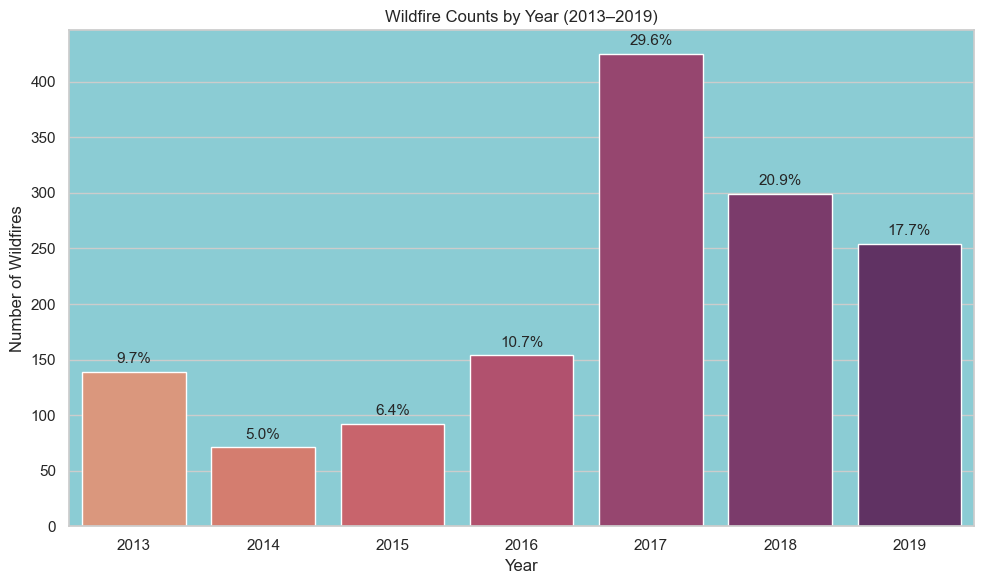

In [308]:
wildfires_real = wildfire[wildfire["WildfireOccurred"] == 1]
wildfires_sim = wildfire[wildfire["WildfireOccurred"] == 0]

wildfire_counts = wildfires_real["ArchiveYear"].value_counts().sort_index()
total = wildfire_counts.sum()

plt.figure(figsize=(10, 6))
plt.gca().set_facecolor("#8bccd4")
ax = sns.countplot(data=wildfires_real, x="ArchiveYear", palette="flare")

# Add percentage labels on top of each bar
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        percent = (height / total) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 5,
            f"{percent:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.title("Wildfire Counts by Year (2013–2019)")
plt.xlabel("Year")
plt.ylabel("Number of Wildfires")
plt.tight_layout()
plt.show()

# Wildfire Frequency by Year

This histogram shows the number of wildfire events from 2013-2019.

Which years experienced the most wildfire activity:

 - From the pie chart it seems like 2017 was the year with the most wildfires, and 2014 with the least, we will likely have to see the weather patterns for those 2 years and see if they show noticeable differences, or it's really by chance.


This level of analysis helps set the stage for deeper questions:
 - Were more fires caused by worsening weather conditions? Did certain regions burn more in some years?

C:\Users\soka\AppData\Local\Temp\ipykernel_45832\206408934.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=wildfires_real, x="Region", palette=['red', 'blue', 'green', 'purple'])


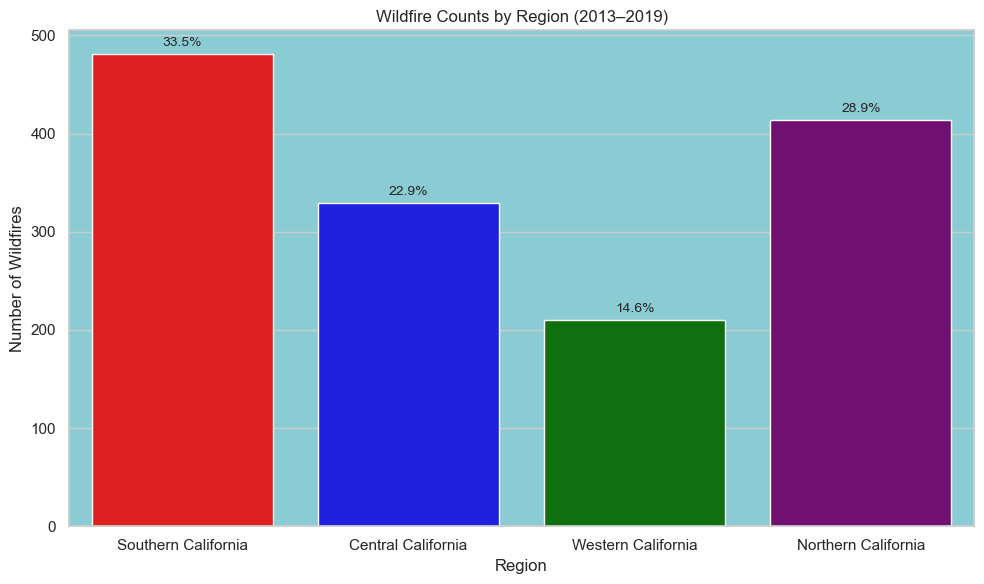

In [409]:
wildfire_counts = wildfires_real["Region"].value_counts().sort_index()
total = wildfire_counts.sum()

plt.figure(figsize=(10, 6))
plt.gca().set_facecolor("#8bccd4")
ax = sns.countplot(data=wildfires_real, x="Region", palette=['red', 'blue', 'green', 'purple'])

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        percent = (height / total) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 5,
            f"{percent:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.title("Wildfire Counts by Region (2013–2019)")
plt.xlabel("Region")
plt.ylabel("Number of Wildfires")
plt.tight_layout()
plt.show()


### Wildfire trends by Regions

In this analysis we want to see, how wildfire events can vary by region or not, which areas are more prone to wildfires and which ones are least prone, and the reasoning behind, whether there are weather pattern correlations behind it or not. It shows us the direction proportional amount of wildfires from our dataset here, and we can see that Southern California is the most prone to wildfires accounting for 33.5% of the total wildfires, but it is not that far ahead compared to Northern California with 28.9%. The least prone is Western California roughly about a little more than 200 (14.6%).

C:\Users\soka\AppData\Local\Temp\ipykernel_45832\4220149371.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wildfires_real, x="Region", y="Temperature", palette=['red', 'blue','green', 'purple'], ax=axs[0])
C:\Users\soka\AppData\Local\Temp\ipykernel_45832\4220149371.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45)
C:\Users\soka\AppData\Local\Temp\ipykernel_45832\4220149371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wildfires_real, x="Region", y="WindSpeed", palette=['red', 'blue','green', 'purple'], ax=axs[1])
C:\Users\

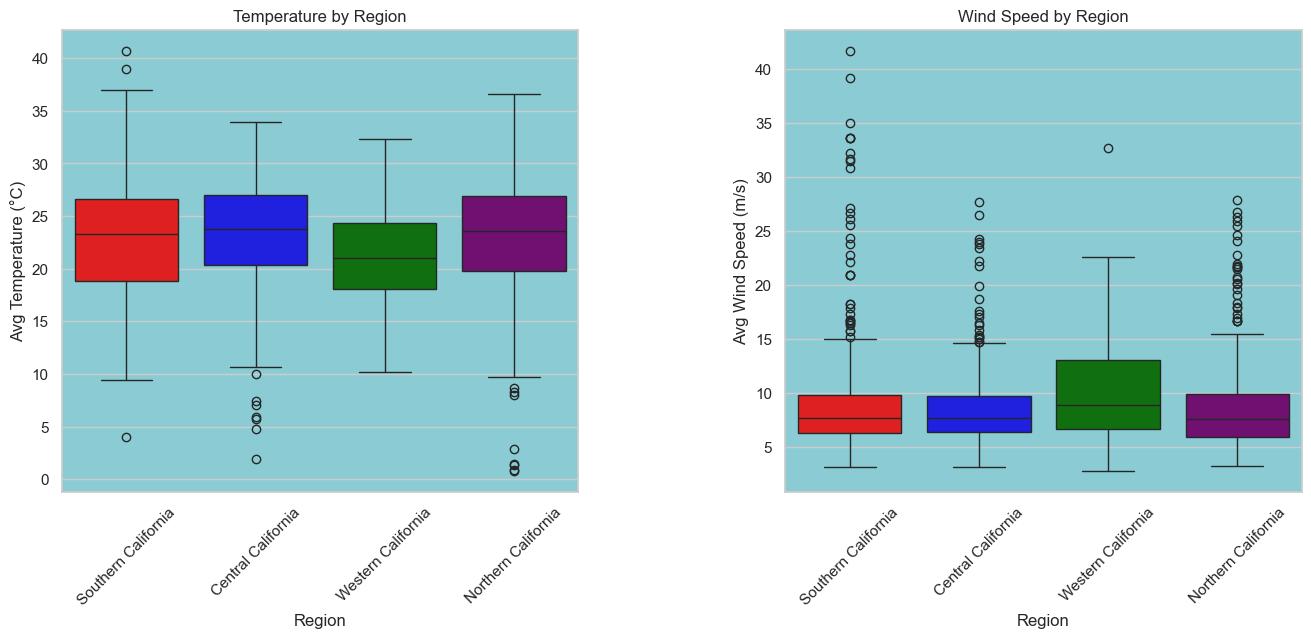

In [411]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
plt.gca().set_facecolor("#8bccd4")
axs[0].set_facecolor("#8bccd4")
plt.subplots_adjust(wspace=0.4)

# Temperature boxplot
sns.boxplot(data=wildfires_real, x="Region", y="Temperature", palette=['red', 'blue','green', 'purple'], ax=axs[0])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45)
axs[0].set_title("Temperature by Region")
axs[0].set_ylabel("Avg Temperature (°C)")

# WindSpeed boxplot
sns.boxplot(data=wildfires_real, x="Region", y="WindSpeed", palette=['red', 'blue','green', 'purple'], ax=axs[1])
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45)
axs[1].set_title("Wind Speed by Region")
axs[1].set_ylabel("Avg Wind Speed (m/s)")

plt.show()

### Lets take a look at simulated versions

C:\Users\soka\AppData\Local\Temp\ipykernel_45832\3104183943.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wildfires_sim, x="Region", y="Temperature", order=['Southern California','Central California', 'Western California','Northern California'],
C:\Users\soka\AppData\Local\Temp\ipykernel_45832\3104183943.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45)
C:\Users\soka\AppData\Local\Temp\ipykernel_45832\3104183943.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wildfires_sim, x="Region", y="WindSpeed", order=['Southern Califo

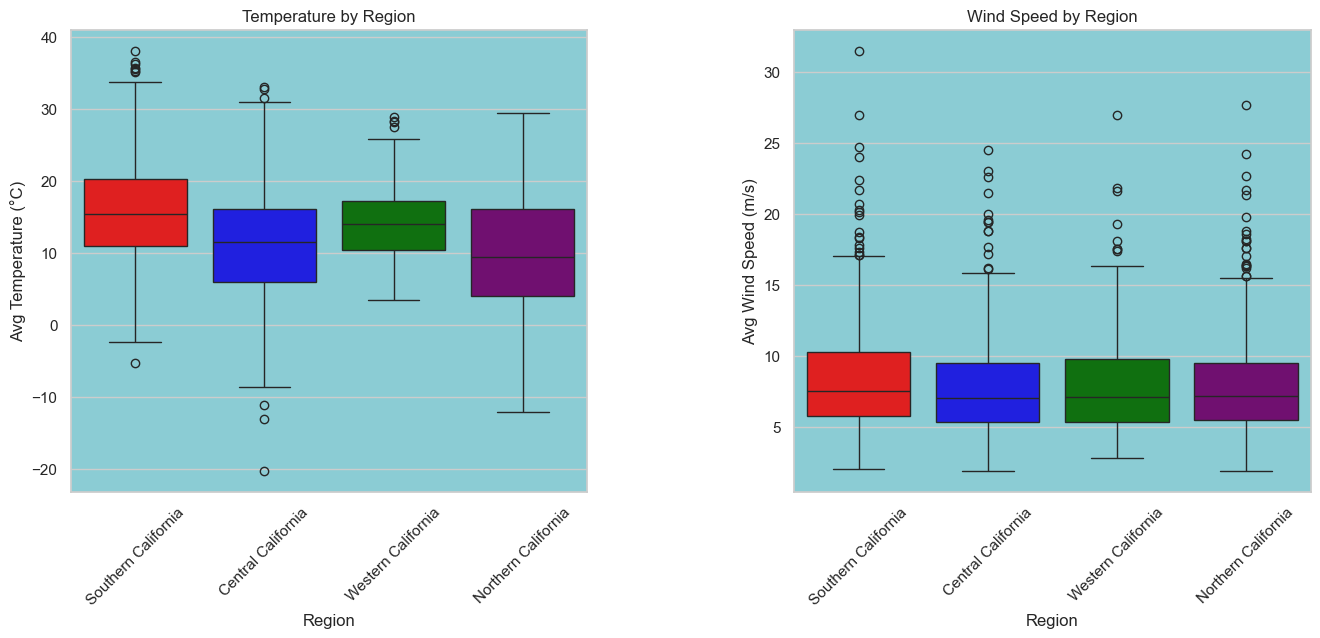

In [384]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
plt.gca().set_facecolor("#8bccd4")
axs[0].set_facecolor("#8bccd4")
plt.subplots_adjust(wspace=0.4)

# Temperature boxplot
sns.boxplot(data=wildfires_sim, x="Region", y="Temperature", order=['Southern California','Central California', 'Western California','Northern California'],
            palette=['red', 'blue','green', 'purple'], ax=axs[0])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45)
axs[0].set_title("Temperature by Region")
axs[0].set_ylabel("Avg Temperature (°C)")

# WindSpeed boxplot
sns.boxplot(data=wildfires_sim, x="Region", y="WindSpeed", order=['Southern California','Central California', 'Western California','Northern California'],
            palette=['red', 'blue','green', 'purple'], ax=axs[1])
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45)
axs[1].set_title("Wind Speed by Region")
axs[1].set_ylabel("Avg Wind Speed (m/s)")

plt.show()

### Regional Weather pattern trends

- The boxplots above shows the comparison of temperature between the regions, they all seem relatively consistenly similar across the regions, although clearly we know that Southern Caliofornia has the most wildfires yet it doesn't show a dramatic temperature advantage between the others, although it is the highest among them suggesting that maybe the small difference is the reason, other variables are likely involved.

- In contrast though, Southern California displays more extreme wind speed outlliers, which may be contribute to wildfires occuring, wind can almost certainly exacerbate wildfires, this makes it a factor for the high wildfire activity in the region. Other regions Northern and Central California show similar windspeed distrubtion realtive to their wildfire occurences

- Humidity and precipition showed no plausible or correlated insights / analysis.

### Non-wildfire Regions

- From the graphs we can essentially rule out that even on days where wildfires didn't occur, the temperature and windspeed stayed relatively stayed consistenly similar, Southern California is known to just have higher temperature and windspeed, which may be the main small factor in why this area expierence more wildfires than other regions.

- I went ahead and did the same graphs for season but it did not tell new critical information, it tells the similar story the only significantly noticeable details was that during the winter season on a wildfire day the temperature was much lower vs a normal day.

C:\Users\soka\AppData\Local\Temp\ipykernel_45832\3321421452.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wildfires_real, x="Season", y="Temperature",
C:\Users\soka\AppData\Local\Temp\ipykernel_45832\3321421452.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45)
C:\Users\soka\AppData\Local\Temp\ipykernel_45832\3321421452.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wildfires_real, x="Season", y="WindSpeed",
C:\Users\soka\AppData\Local\Temp\ipykernel_45832\3321421452.py:16: UserWarning: set_ticklabels() should only be used 

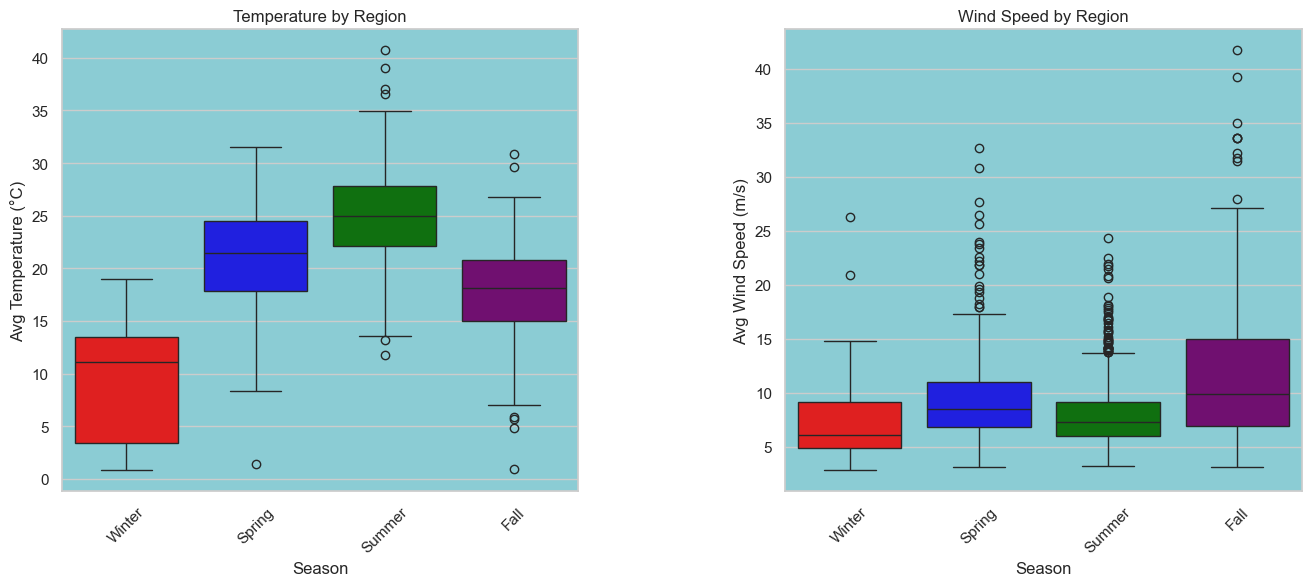

In [387]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
plt.gca().set_facecolor("#8bccd4")
axs[0].set_facecolor("#8bccd4")
plt.subplots_adjust(wspace=0.4)

# Temperature boxplot
sns.boxplot(data=wildfires_real, x="Season", y="Temperature", 
            palette=['red', 'blue','green', 'purple'], ax=axs[0])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45)
axs[0].set_title("Temperature by Region")
axs[0].set_ylabel("Avg Temperature (°C)")

# WindSpeed boxplot
sns.boxplot(data=wildfires_real, x="Season", y="WindSpeed", 
            palette=['red', 'blue','green', 'purple'], ax=axs[1])
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45)
axs[1].set_title("Wind Speed by Region")
axs[1].set_ylabel("Avg Wind Speed (m/s)")

plt.show()

### Seasonal Trend

Just from the look of this we can already tell that overr 800+ wildfires occured in the summer season, and less than 100 during winter season, and although we can draw our own conclusions from this, we can measure it to help us quantify it, it'll likely due to high levels of temperature during the summer compared to winter. 

C:\Users\soka\AppData\Local\Temp\ipykernel_45832\2182657482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=wildfires_real, x="Season", order=["Winter", "Spring", "Summer", "Fall"], palette=["blue","green","orange","brown"])


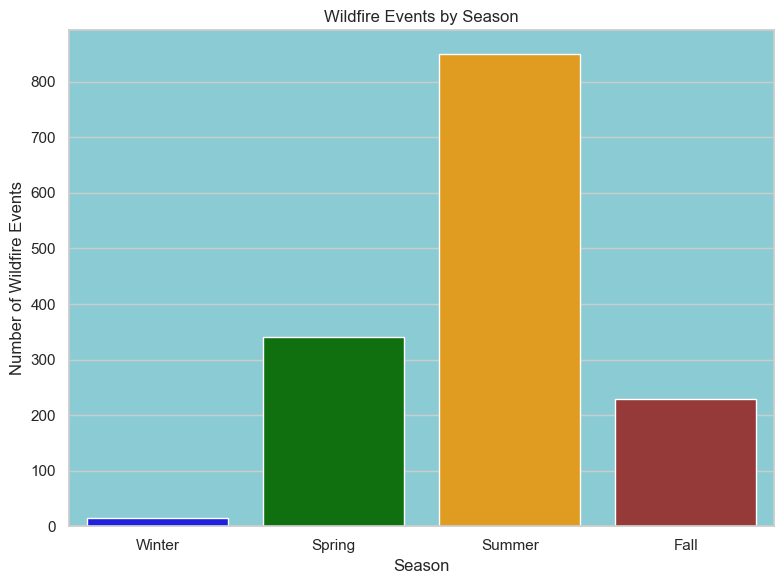

In [ ]:
plt.figure(figsize=(8, 6))
plt.gca().set_facecolor("#8bccd4")
sns.countplot(data=wildfires_real, x="Season", order=["Winter", "Spring", "Summer", "Fall"], palette=["blue","green","orange","brown"])

plt.title("Wildfire Events by Season")
plt.xlabel("Season")
plt.ylabel("Number of Wildfire Events")
plt.tight_layout()
plt.show()

C:\Users\soka\AppData\Local\Temp\ipykernel_45832\2354042413.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


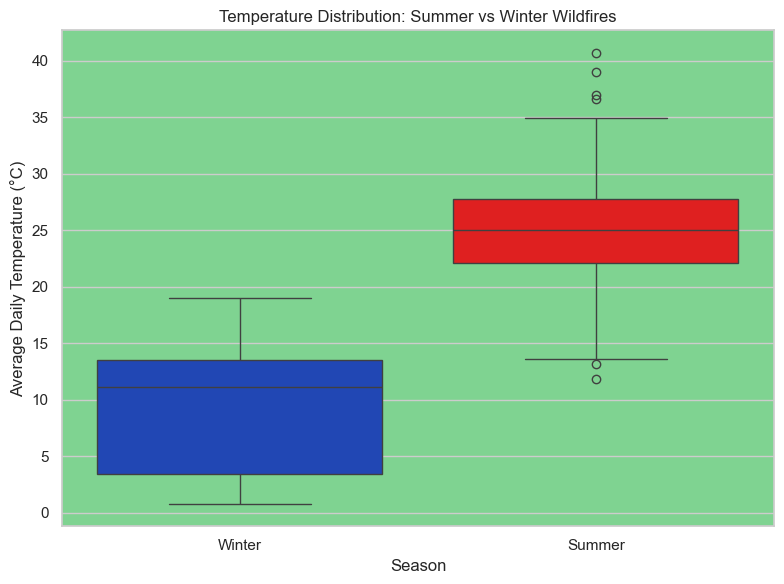

In [318]:
plt.figure(figsize=(8, 6))
plt.gca().set_facecolor("#7fd391")
sns.boxplot(
    data=wildfires_real[wildfires_real["Season"].isin(["Summer", "Winter"])], # type: ignore
    x="Season", y="Temperature", 
    palette=["#083CCC", "#FF0000"]
)
plt.title("Temperature Distribution: Summer vs Winter Wildfires")
plt.xlabel("Season")
plt.ylabel("Average Daily Temperature (°C)")
plt.tight_layout()
plt.show()

### Mean temperature is noticeably higher in Summer compared to Winter. 

 Therefore we can conclude that that temperature plays a big role in determining the wildfire occurences during the summer season, a higher temperature are more prone to cause wildfires and vice versa. 

Lets do some scatterplots to draw insights, they are great for continouous-variable relationships, to see if one or more independent variable affects another variable such as temperature with acresburned.

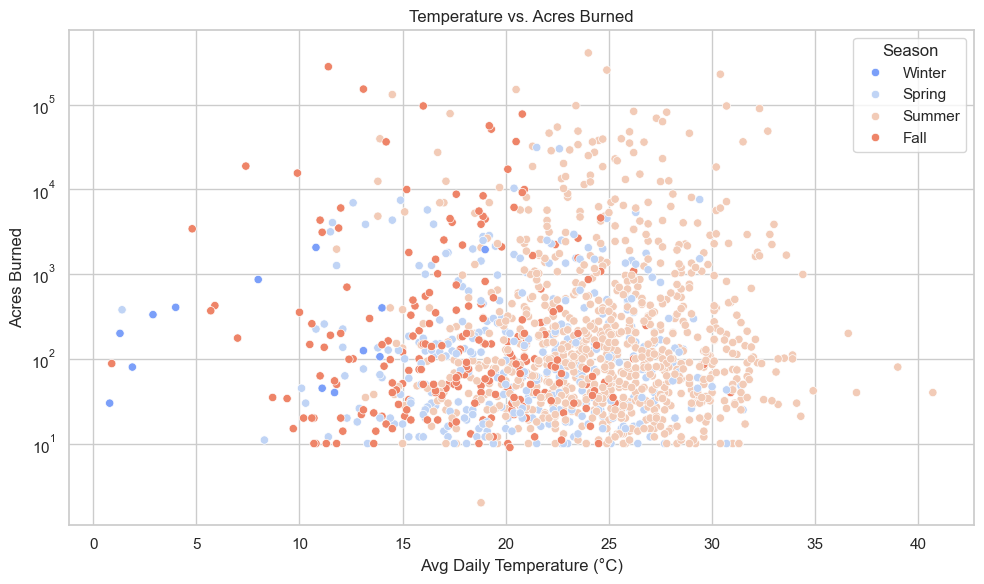

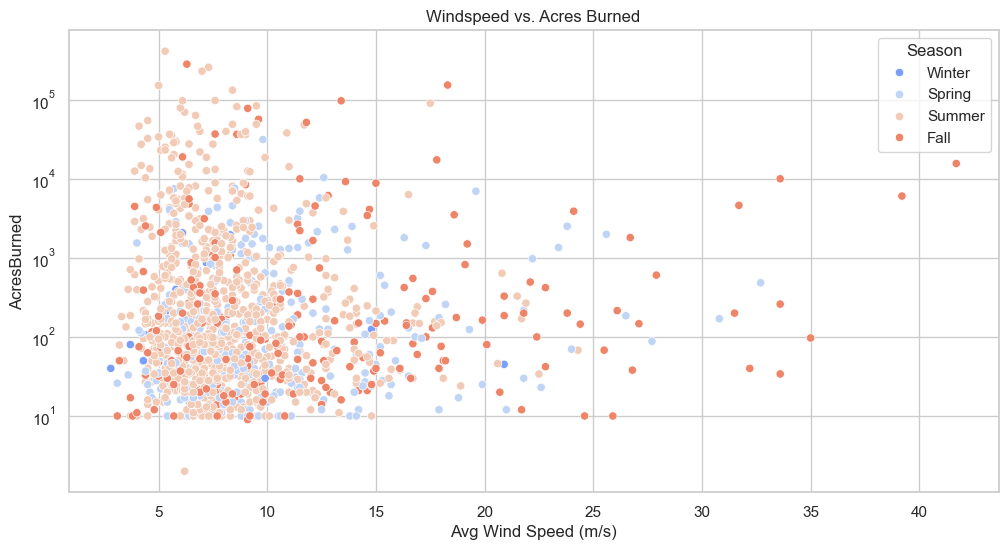

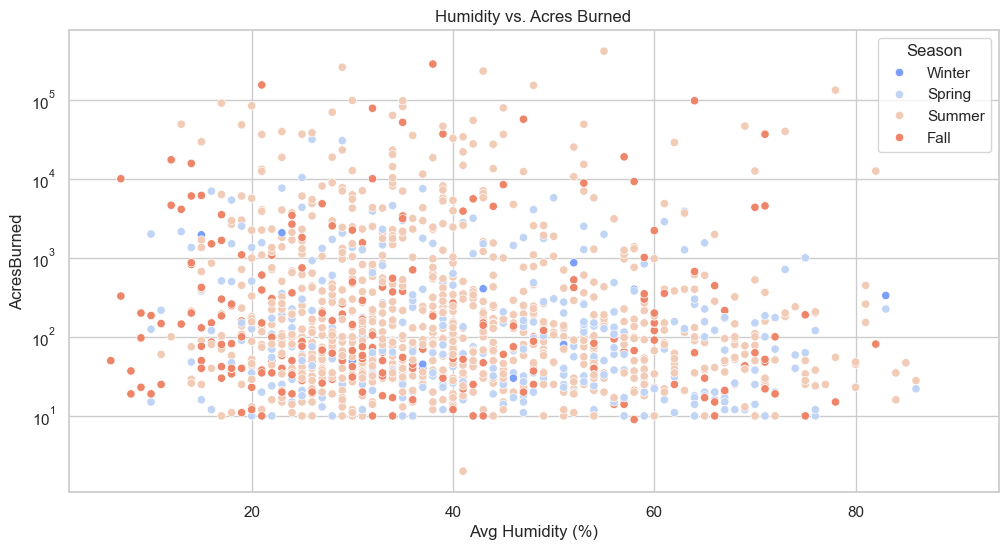

In [367]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=wildfires_real, x="Temperature", y="AcresBurned", hue="Season", palette="coolwarm")

plt.title("Temperature vs. Acres Burned")
plt.xlabel("Avg Daily Temperature (°C)")
plt.ylabel("Acres Burned")
plt.yscale("log") 
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=wildfires_real, x="WindSpeed", y="AcresBurned", hue="Season", palette="coolwarm")
plt.title("Windspeed vs. Acres Burned")
plt.xlabel("Avg Wind Speed (m/s)")
plt.yscale("log") 

plt.figure(figsize=(12, 6))
sns.scatterplot(data=wildfires_real, x="Humidity", y="AcresBurned", hue="Season", palette="coolwarm")
plt.title("Humidity vs. Acres Burned")
plt.xlabel("Avg Humidity (%)")
plt.yscale("log") 

Scatterplot Analysis: 

Temperature vs. Acres Burned

- Summer fires dominate,especially at temperatures above 25°C, but we already knew this from our earlier statiscal analysis
- The largest wildfires burning over 10,000 acres are clustered in high-temperature conditions
- Winter fires are rare, tend to happen at lower temperatures, and are generally small in size

The log scale on the y-axis shows how small temperature differences can correspond to bigger fire sizes.
This shows hotter conditions significantly increase wildfire severity.

Windspeed vs Acres Burned

- Windspeed doesn't determine the wildfire being more severe, we can draw out that majority of the wildfires is clustered around 5-10 (m/s), even the extreme wildfires, meaning that high wind speeds above 10+ didn't seem to exacerbate wildfires, although windspeed causing wildfires is a different insight.

Humidity vs. Acres

- From the scatterplot we can draw that most of the wildfires seems to occur for humidity below 40%, and practically we can also draw that wildfires isn't inherently by humidity, the wildfire distrubution is scattered very evenly among the chart, it isn't too heavily clustered at a single point in the chart. Large wildfires are uncommon when humidity when humidity is high there is more water vapors there wildfire not spreading easily since it'll be harder for it to be flammable.

In [422]:
wildfire.corr(numeric_only=True)    

,Latitude,Longitude,ArchiveYear,AcresBurned,WildfireOccurred,Temperature,Humidity,WindSpeed,Precipitation,Year
Latitude,1.000000,-0.829443,-0.003713,0.037309,-0.010721,-0.165774,0.123252,-0.035219,0.113403,-0.003713
Longitude,-0.829443,1.000000,-0.024972,-0.039196,-0.042505,0.113042,-0.248605,0.019686,-0.097683,-0.024972
ArchiveYear,-0.003713,-0.024972,1.000000,0.016982,0.244987,0.066475,-0.012250,0.184429,0.047413,1.000000
AcresBurned,0.037309,-0.039196,0.016982,1.000000,0.117573,0.065333,-0.055387,-0.008468,-0.021201,0.016982
WildfireOccurred,-0.010721,-0.042505,0.244987,0.117573,1.000000,0.580663,-0.420343,0.105607,-0.187090,0.244987
Temperature,-0.165774,0.113042,0.066475,0.065333,0.580663,1.000000,-0.636711,-0.022178,-0.264918,0.066475
Humidity,0.123252,-0.248605,-0.012250,-0.055387,-0.420343,-0.636711,1.000000,-0.084524,0.380886,-0.012250
WindSpeed,-0.035219,0.019686,0.184429,-0.008468,0.105607,-0.022178,-0.084524,1.000000,0.176878,0.184429
Precipitation,0.113403,-0.097683,0.047413,-0.021201,-0.187090,-0.264918,0.380886,0.176878,1.000000,0.047413
Year,-0.003713,-0.024972,1.000000,0.016982,0.244987,0.066475,-0.012250,0.184429,0.047413,1.000000


<Axes: >

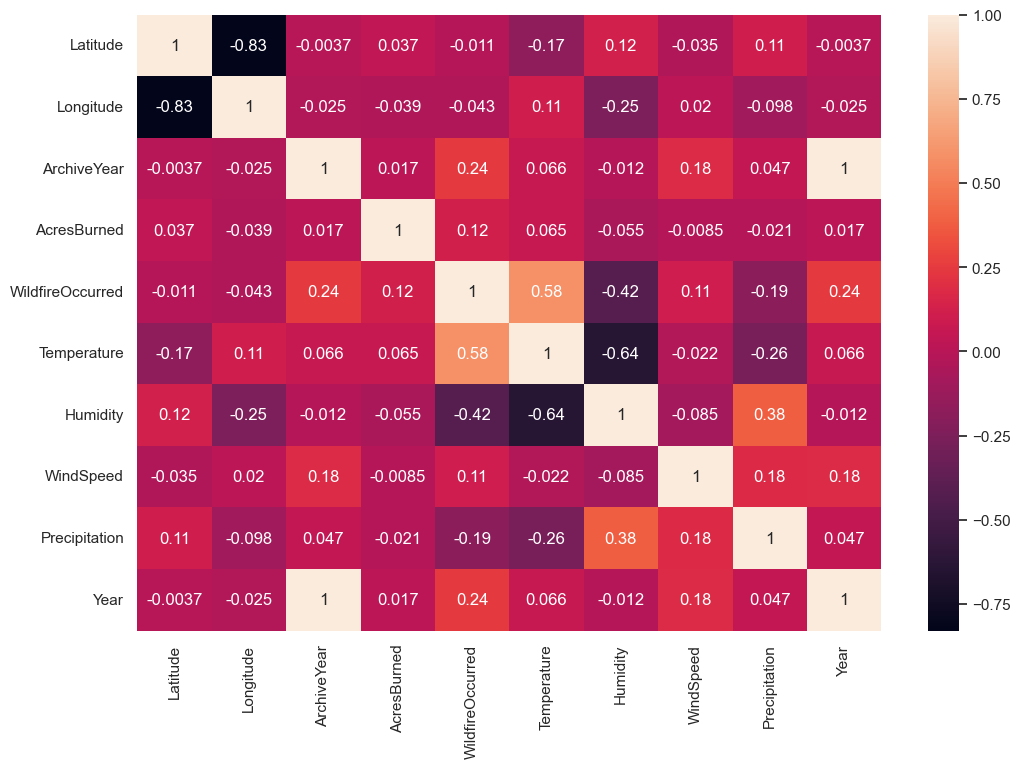

In [428]:
plt.figure(figsize=(12, 8))
sns.heatmap(wildfire.corr(numeric_only=True), annot=True,)

### Correlation Heatmap Summary

- Temperature and WildfireOccured has a moderate positive correlation with 0.58, suggesting, showing that higher temperatures are the correlated to actual fire events

- Temperature has a strong negative correlation with humidity -0.64, as temperatuer increases humidity tends to decrease, this make sense high temperature would result in a drier air, and vice versa, where humidity is high the air is more wet and temperature is lower.

- There is a moderate negative correlative with humidity and wildfireOccured, -0.42. When humidity is high, wildfire occurences tends to decrease, moist air makes it harder for fire to ignite, when humidity is low, dry air wildfires are more likely to ignite, 

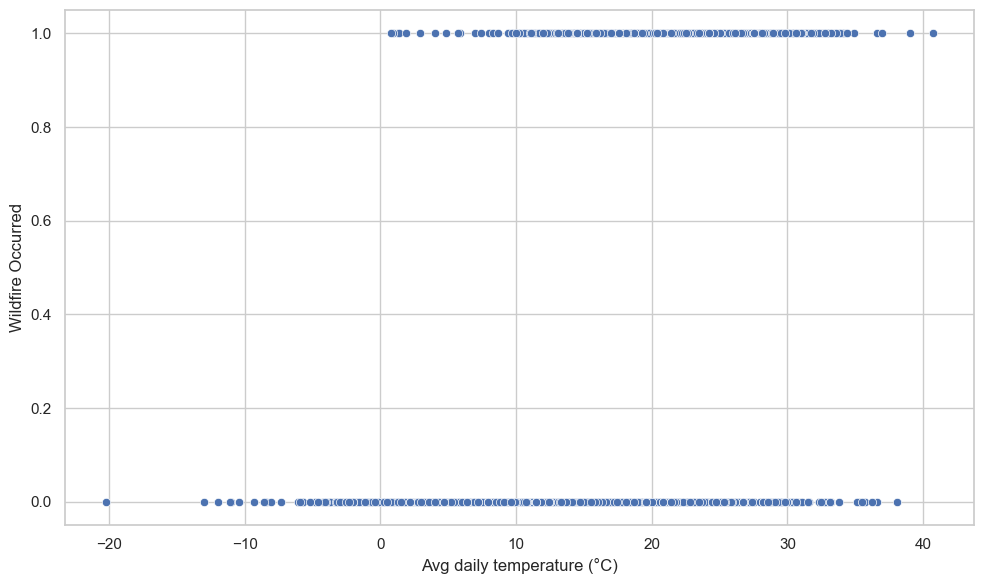

In [429]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=wildfire, x="Temperature", y="WildfireOccurred",)
plt.xlabel("Avg daily temperature (°C)")
plt.ylabel("Wildfire Occurred")
# plt.yscale("log") 
plt.tight_layout()
plt.show()

In [431]:
wildfire = wildfire.drop(columns=["Year"])

In [432]:
wildfire.head()

,Latitude,Longitude,ArchiveYear,Started,AcresBurned,Counties,WildfireOccurred,Region,Season,Date,Temperature,Humidity,WindSpeed,Precipitation
0,40.785933,-121.017469,2013,2013-01-01 08:14:00+00:00,0,Lassen,0,Northern California,Winter,1/1/2013,-11.0,79.0,7.6,0.0
1,33.469231,-115.114638,2013,2013-01-02 16:51:00+00:00,0,Riverside,0,Southern California,Winter,1/2/2013,7.2,23.0,15.0,0.0
2,40.816333,-121.838142,2013,2013-01-04 15:07:00+00:00,0,Shasta,0,Northern California,Winter,1/4/2013,-2.2,76.0,7.9,0.0
3,34.186179,-118.661168,2013,2013-01-06 17:30:00+00:00,0,Los Angeles,0,Southern California,Winter,1/6/2013,9.2,76.0,6.2,0.9
4,37.507826,-122.105244,2013,2013-01-08 05:47:00+00:00,0,Alameda,0,Western California,Winter,1/8/2013,9.1,84.0,3.3,0.0


In [433]:
wildfire.to_csv('wildfire_data_eda.csv', index = False)

# Report

In this Exploratory Data Analysis (EDA) I visualized real and simulated wildfire events in California between 2013 and 2019, with a focus on temporal geographic and environmental patterns that play a role in wildfire occurrence and severity. The original dataset was enhanced with historical weather features such as temperature, humidity, wind speed, and precipitation using the Open-Meteo API, for deeper wildfire insights. Summer was by far the most wildfire-prone season, with over 800 events, while winter had the fewest. This trend aligned closely with higher average temperatures observed during summer months, further suggesting that heat plays a central role in wildfire activity.

Regionally, Southern California accounted for the largest share of wildfires 33.5%, slightly ahead of Northern California 28.9%. However, average temperature and wind speed distributions across regions were fairly similar. One notable difference was that Southern California had more wind speed outliers, which could explain its elevated wildfire rate despite only modest differences in median temperature. However, humidity and precipitation distributions were not strongly associated with region-specific fire patterns but were more useful when analyzed directly against fire occurrence or severity.

Scatterplots and correlation heatmaps revealed that temperature had a moderate positive correlation of 0.58 with wildfire occurrence, confirming it as the strongest predictor among the four weather features. Humidity had a strong negative correlation with temperature -0.64 and a moderate negative correlation with wildfire occurrence -0.42, reflecting the reality that dry air (low humidity) makes ignition and spread more likely. While wind speed did not correlate with fire severity (acres burned), it may still play a role in fire initiation or geographic spread. Ultimately, temperature stood out as the most influential weather factor in predicting both wildfire frequency and size.

Overall, EDA provided a lot of insights, and all of it would not have been possible with just the original dataset, combining the dataset, and manually creating new columns to create more insights. Although we were limited to strictly weather patterns in this project, in the future combining other wildfire events factors just vegetation or population density would be good to explore.